In [9]:
import pandas as pd

In [10]:
column_names = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
 ]

car_data = pd.read_csv("car.csv", names=column_names)

print("The First 5 rows of the dataset:")
print(car_data.head())

The First 5 rows of the dataset:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [11]:
print("The Dataset info:")
print("\nThe Number of cars in each class:")
print(car_data["class"])

The Dataset info:

The Number of cars in each class:
0       unacc
1       unacc
2       unacc
3       unacc
4       unacc
        ...  
1723     good
1724    vgood
1725    unacc
1726     good
1727    vgood
Name: class, Length: 1728, dtype: object


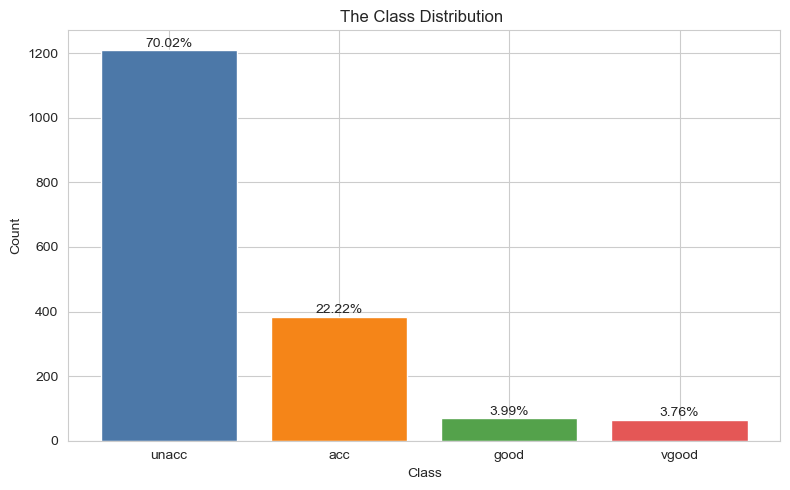

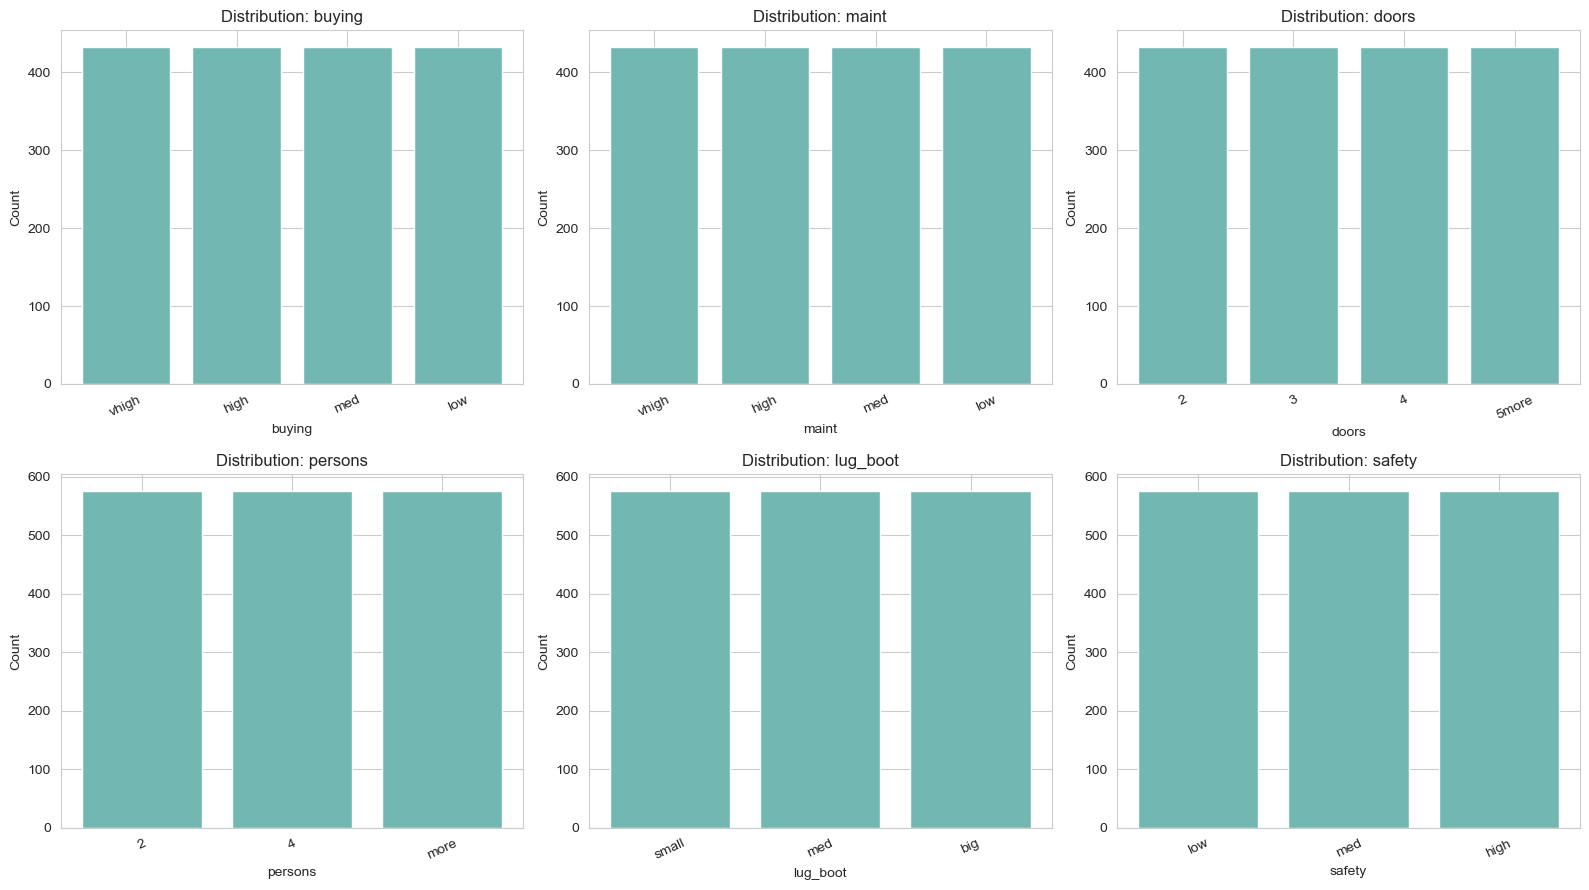

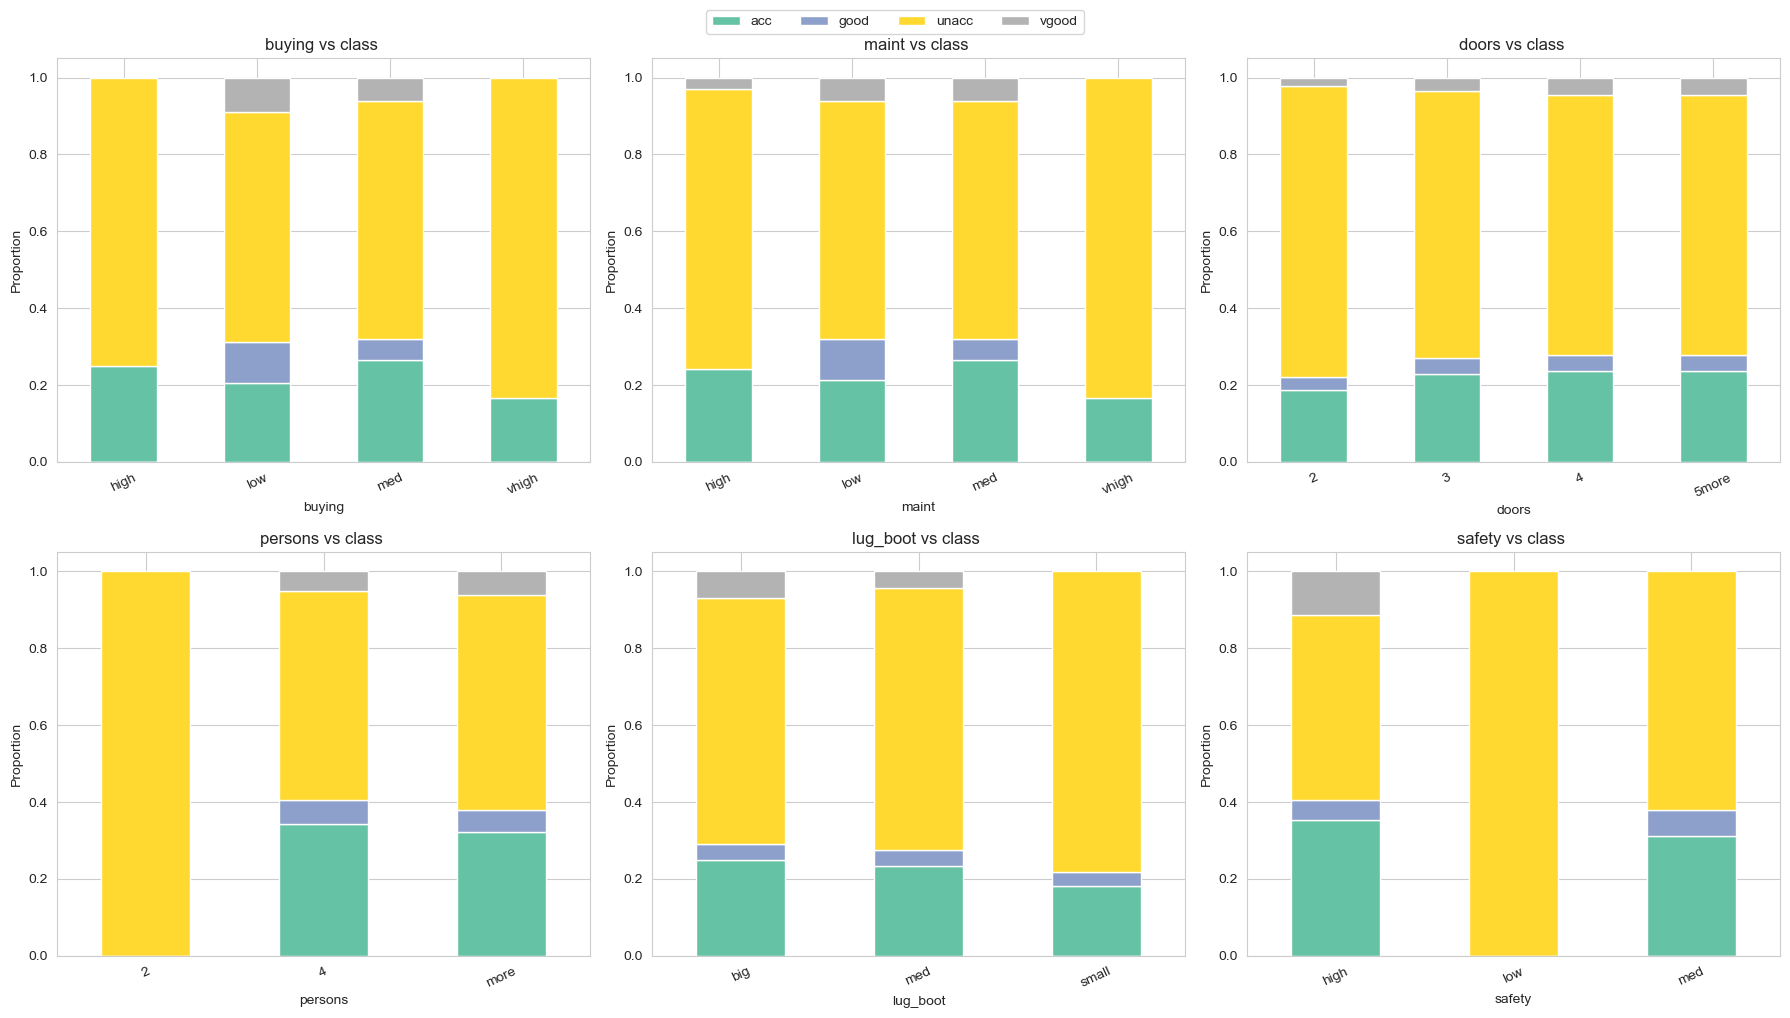

The Feature frequency distribution (%):

buying:
buying
vhigh    25.0
high     25.0
med      25.0
low      25.0
Name: proportion, dtype: float64

maint:
maint
vhigh    25.0
high     25.0
med      25.0
low      25.0
Name: proportion, dtype: float64

doors:
doors
2        25.0
3        25.0
4        25.0
5more    25.0
Name: proportion, dtype: float64

persons:
persons
2       33.33
4       33.33
more    33.33
Name: proportion, dtype: float64

lug_boot:
lug_boot
small    33.33
med      33.33
big      33.33
Name: proportion, dtype: float64

safety:
safety
low     33.33
med     33.33
high    33.33
Name: proportion, dtype: float64


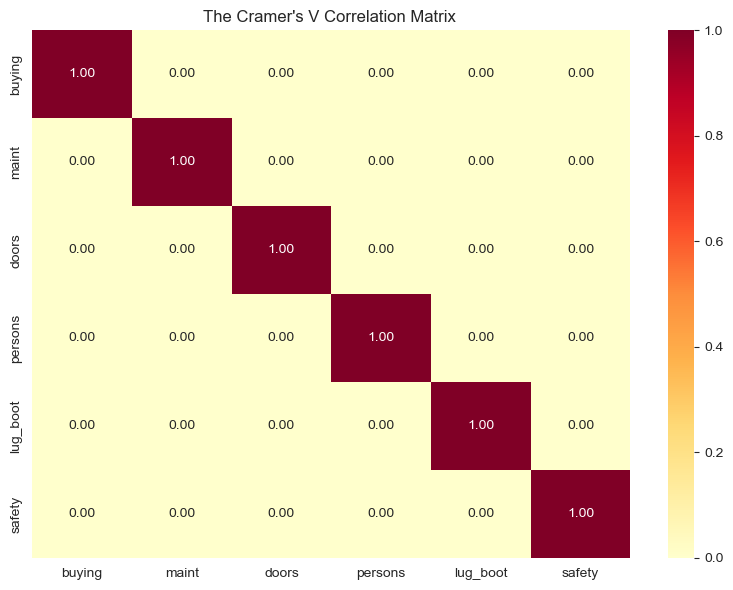

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


if "car_data" not in globals():
    column_names = [
        "buying",
        "maint",
        "doors",
        "persons",
        "lug_boot",
        "safety",
        "class"
    ]
    car_data = pd.read_csv("car.csv", names=column_names)


feature_cols = ["buying", "maint", "doors", "persons", "lug_boot", "safety"]
sns.set_style("whitegrid")

class_counts = car_data["class"].value_counts()
class_pct = (class_counts / len(car_data) * 100).round(2)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
for i, (label, count) in enumerate(class_counts.items()):
    plt.text(i, count + 10, f"{class_pct[label]}%", ha="center", fontsize=10)
plt.title("The Class Distribution ")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    freq = car_data[col].value_counts()
    axes[i].bar(freq.index.astype(str), freq.values, color="#72B7B2")
    axes[i].set_title(f"Distribution: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")


    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

legend_handles = None
legend_labels = None

for i, col in enumerate(feature_cols):
    relation = pd.crosstab(car_data[col], car_data["class"], normalize="index")
    relation.plot(kind="bar", stacked=True, ax=axes[i], colormap="Set2", legend=False)
    axes[i].set_title(f"{col} vs class ")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis="x", rotation=25)

    if legend_handles is None:
        legend_handles, legend_labels = axes[i].get_legend_handles_labels()

if legend_handles and legend_labels:
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=len(legend_labels), bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()


print("The Feature frequency distribution (%):")
for col in feature_cols:
    print(f"\n{col}:")
    print((car_data[col].value_counts(normalize=True) * 100).round(2))


def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return (chi2 / (n * (min(k - 1, r - 1)))) ** 0.5

cramers_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)
for col1 in feature_cols:
    for col2 in feature_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(car_data[col1], car_data[col2])

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("The Cramer's V Correlation Matrix ")
plt.tight_layout()
plt.show()

In [13]:
encoded_data = pd.get_dummies(car_data, drop_first=False)

print("The Encoded version of the data:")
print(encoded_data.head())

The Encoded version of the data:
   buying_high  buying_low  buying_med  buying_vhigh  maint_high  maint_low  \
0        False       False       False          True       False      False   
1        False       False       False          True       False      False   
2        False       False       False          True       False      False   
3        False       False       False          True       False      False   
4        False       False       False          True       False      False   

   maint_med  maint_vhigh  doors_2  doors_3  ...  lug_boot_big  lug_boot_med  \
0      False         True     True    False  ...         False         False   
1      False         True     True    False  ...         False         False   
2      False         True     True    False  ...         False         False   
3      False         True     True    False  ...         False          True   
4      False         True     True    False  ...         False          True   

   lug_boot

In [14]:
x = pd.get_dummies(car_data.drop("class", axis=1))
y = car_data["class"]

print("The Shape of x:", x.shape)
print("The Shape of y:", y.shape)

The Shape of x: (1728, 21)
The Shape of y: (1728,)


In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("The Training data shape:", x_train.shape)
print("The Testing data shape:", x_test.shape)

print("\nClass distribution in full data (%):")
print(y.value_counts(normalize=True).round(3) * 100)

print("\nClass distribution in y_train (%):")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nClass distribution in y_test (%):")
print(y_test.value_counts(normalize=True).round(3) * 100)

The Training data shape: (1382, 21)
The Testing data shape: (346, 21)

Class distribution in full data (%):
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64

Class distribution in y_train (%):
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64

Class distribution in y_test (%):
class
unacc    69.9
acc      22.3
good      4.0
vgood     3.8
Name: proportion, dtype: float64


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)

decision_tree_predictions = decision_tree_model.predict(x_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)

print("The Decision Tree Accuracy:", decision_tree_accuracy)

The Decision Tree Accuracy: 0.9682080924855492


In [17]:
from sklearn.metrics import classification_report

print("The Classification Report:")
print(classification_report(y_test, decision_tree_predictions))

The Classification Report:
              precision    recall  f1-score   support

         acc       0.96      0.90      0.93        77
        good       0.88      1.00      0.93        14
       unacc       0.98      0.99      0.98       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.97       346
   macro avg       0.95      0.95      0.95       346
weighted avg       0.97      0.97      0.97       346



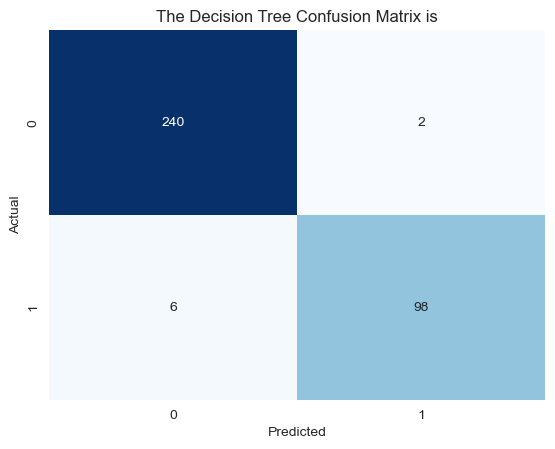

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2x2 confusion matrix via one-vs-rest mapping (unacc vs others)
y_test_binary = (y_test != "unacc").astype(int)
decision_tree_binary = (decision_tree_predictions != "unacc").astype(int)

decision_tree_cm = confusion_matrix(y_test_binary, decision_tree_binary)

ax = sns.heatmap(decision_tree_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("The Decision Tree Confusion Matrix is")
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

logistic_model = LogisticRegression(max_iter=2000, class_weight="balanced")
tree_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
forest_model = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
 )
svm_model = SVC(kernel="rbf", random_state=42, class_weight="balanced")

logistic_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
forest_model.fit(x_train, y_train)
svm_model.fit(x_train, y_train)

logistic_predictions = logistic_model.predict(x_test)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_balanced_accuracy = balanced_accuracy_score(y_test, logistic_predictions)
logistic_f1_macro = f1_score(y_test, logistic_predictions, average="macro")

print("The Logistic Regression Accuracy is:", logistic_accuracy)
print("The Logistic Regression Balanced Accuracy is:", logistic_balanced_accuracy)
print("The Logistic Regression F1 Macro is:", logistic_f1_macro)

The Logistic Regression Accuracy is: 0.8872832369942196
The Logistic Regression Balanced Accuracy is: 0.93314639905549
The Logistic Regression F1 Macro is: 0.8315341901630355


In [20]:
tree_predictions = tree_model.predict(x_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_balanced_accuracy = balanced_accuracy_score(y_test, tree_predictions)
tree_f1_macro = f1_score(y_test, tree_predictions, average="macro")

print("The Decision Tree Accuracy is:", tree_accuracy)
print("The Decision Tree Balanced Accuracy is:", tree_balanced_accuracy)
print("The Decision Tree F1 Macro is:", tree_f1_macro)

The Decision Tree Accuracy is: 0.953757225433526
The Decision Tree Balanced Accuracy is: 0.8957179184451912
The Decision Tree F1 Macro is: 0.9123343220565442


In [21]:
forest_predictions = forest_model.predict(x_test)
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_balanced_accuracy = balanced_accuracy_score(y_test, forest_predictions)
forest_f1_macro = f1_score(y_test, forest_predictions, average="macro")

print("The Random Forest Accuracy is:", forest_accuracy)
print("The Random Forest Balanced Accuracy is:", forest_balanced_accuracy)
print("The Random Forest F1 Macro is:", forest_f1_macro)

The Random Forest Accuracy is: 0.9710982658959537
The Random Forest Balanced Accuracy is: 0.9457928435201164
The Random Forest F1 Macro is: 0.9605828683101411


In [22]:
svm_predictions = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_balanced_accuracy = balanced_accuracy_score(y_test, svm_predictions)
svm_f1_macro = f1_score(y_test, svm_predictions, average="macro")

print("The SVM Accuracy is:", svm_accuracy)
print("The SVM Balanced Accuracy is:", svm_balanced_accuracy)
print("The SVM F1 Macro is:", svm_f1_macro)

The SVM Accuracy is: 0.953757225433526
The SVM Balanced Accuracy is: 0.9812573789846517
The SVM F1 Macro is: 0.9595740509276278


In [23]:
model_results = {
    "Logistic Regression": logistic_accuracy,
    "Decision Tree": tree_accuracy,
    "Random Forest": forest_accuracy,
    "SVM": svm_accuracy
}

imbalance_results = pd.DataFrame(
    {
        "accuracy": [logistic_accuracy, tree_accuracy, forest_accuracy, svm_accuracy],
        "balanced_accuracy": [
            logistic_balanced_accuracy,
            tree_balanced_accuracy,
            forest_balanced_accuracy,
            svm_balanced_accuracy
        ],
        "f1_macro": [
            logistic_f1_macro,
            tree_f1_macro,
            forest_f1_macro,
            svm_f1_macro
        ]
    },
    index=["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
)

print("The Model Accuracy results are:")
print(model_results)

print("\nImbalance-focused metrics are:")
print(imbalance_results.round(4))

The Model Accuracy results are:
{'Logistic Regression': 0.8872832369942196, 'Decision Tree': 0.953757225433526, 'Random Forest': 0.9710982658959537, 'SVM': 0.953757225433526}

Imbalance-focused metrics are:
                     accuracy  balanced_accuracy  f1_macro
Logistic Regression    0.8873             0.9331    0.8315
Decision Tree          0.9538             0.8957    0.9123
Random Forest          0.9711             0.9458    0.9606
SVM                    0.9538             0.9813    0.9596


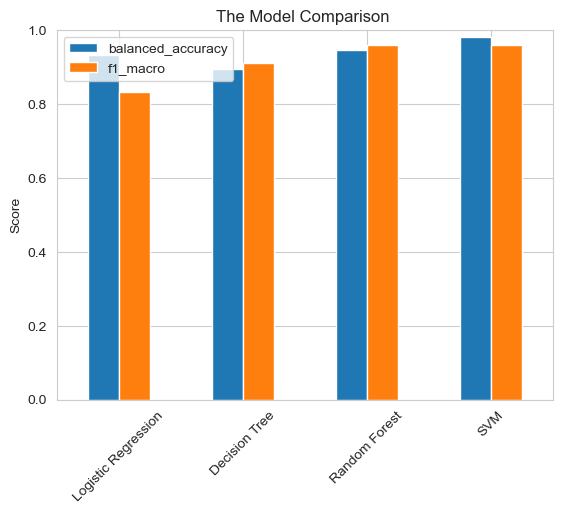

In [24]:
imbalance_results[["balanced_accuracy", "f1_macro"]].plot(kind="bar")
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("The Model Comparison ")
plt.ylim(0, 1)
plt.show()

Per-class recall:
       Logistic Regression  Decision Tree  Random Forest    SVM
unacc               0.8884         0.9835         0.9835  0.938
acc                 0.8442         0.8961         0.9481  0.987
good                1.0000         0.8571         0.9286  1.000
vgood               1.0000         0.8462         0.9231  1.000

Per-class F1-score:
       Logistic Regression  Decision Tree  Random Forest     SVM
unacc               0.9409         0.9794         0.9835  0.9680
acc                 0.7738         0.8961         0.9359  0.9048
good                0.8235         0.8571         0.9630  0.9655
vgood               0.7879         0.9167         0.9600  1.0000


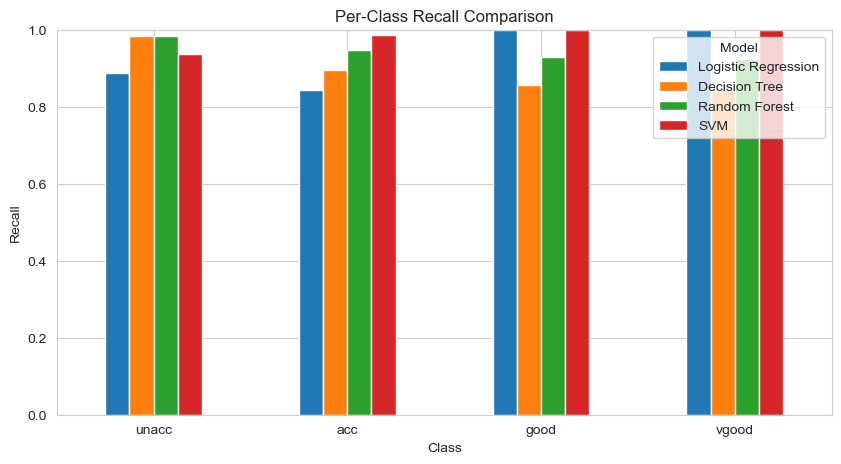

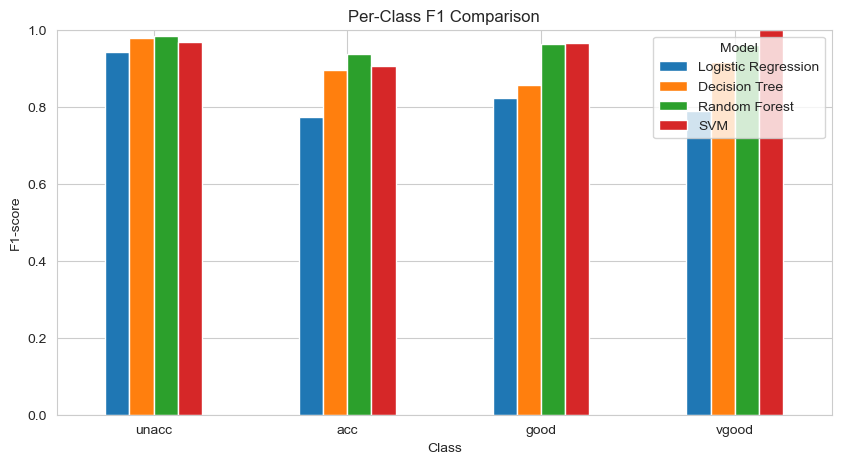

In [25]:
from sklearn.metrics import classification_report


all_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions,
    "SVM": svm_predictions
}

class_order = list(y.value_counts().index)

per_class_recall = pd.DataFrame(index=class_order)
per_class_f1 = pd.DataFrame(index=class_order)

for model_name, pred_values in all_predictions.items():
    report = classification_report(
        y_test, pred_values, output_dict=True, zero_division=0
    )
    per_class_recall[model_name] = [report[class_name]["recall"] for class_name in class_order]
    per_class_f1[model_name] = [report[class_name]["f1-score"] for class_name in class_order]

print("Per-class recall:")
print(per_class_recall.round(4))

print("\nPer-class F1-score:")
print(per_class_f1.round(4))

per_class_recall.plot(kind="bar", figsize=(10, 5))
plt.title("Per-Class Recall Comparison")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

per_class_f1.plot(kind="bar", figsize=(10, 5))
plt.title("Per-Class F1 Comparison")
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(forest_model, x, y, cv=5)

print("The Cross validation accuracy:", cv_scores.mean())

The Cross validation accuracy: 0.7333249560191002


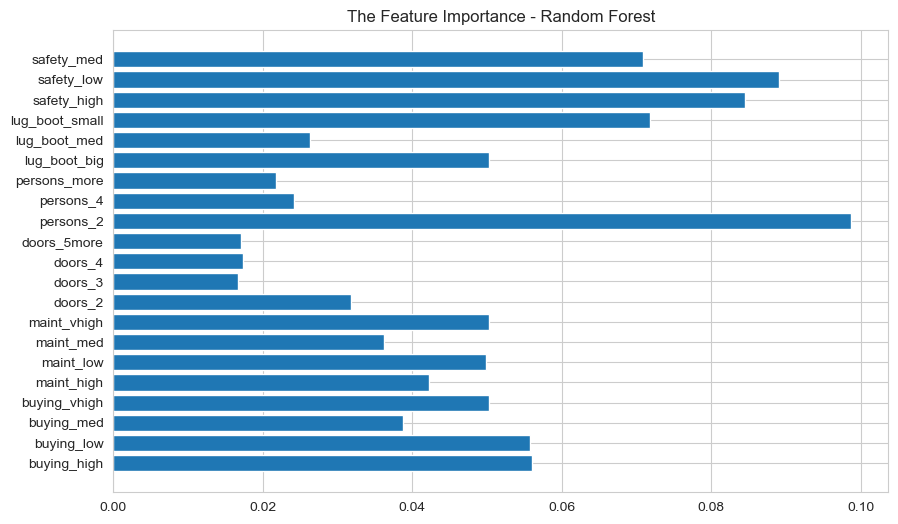

In [27]:
feature_importance_values = forest_model.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance_values)
plt.title("The Feature Importance - Random Forest")
plt.show()

In [28]:
from sklearn.metrics import accuracy_score

all_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "SVM": svm_model
}

final_results = {}

for model_name, current_model in all_models.items():
    current_predictions = current_model.predict(x_test)
    current_accuracy = accuracy_score(y_test, current_predictions)
    final_results[model_name] = current_accuracy

final_results

{'Logistic Regression': 0.8872832369942196,
 'Decision Tree': 0.953757225433526,
 'Random Forest': 0.9710982658959537,
 'SVM': 0.953757225433526}

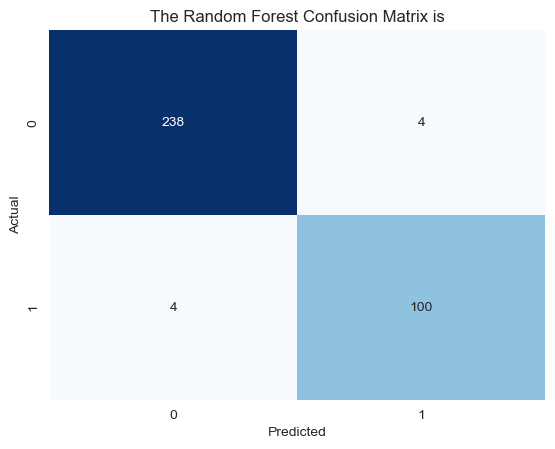

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = forest_model
best_model_predictions = best_model.predict(x_test)

y_test_binary = (y_test != "unacc").astype(int)
best_model_binary = (best_model_predictions != "unacc").astype(int)

best_model_cm = confusion_matrix(y_test_binary, best_model_binary)

ax = sns.heatmap(best_model_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("The Random Forest Confusion Matrix is")
plt.show()

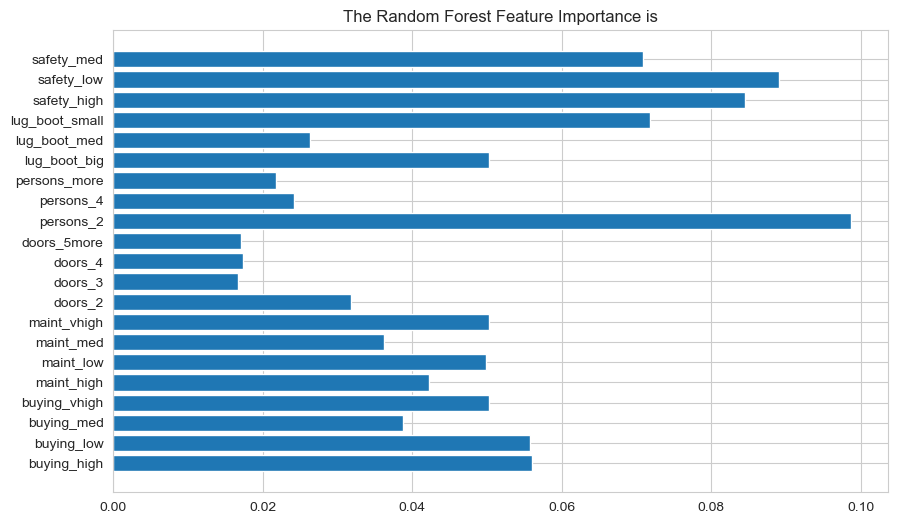

In [30]:
feature_importance_values = forest_model.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance_values)
plt.title("The Random Forest Feature Importance is")
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(forest_model, x, y, cv=5)
print("The 5-Fold CV Accuracy:", cv_scores.mean())

The 5-Fold CV Accuracy: 0.7333249560191002


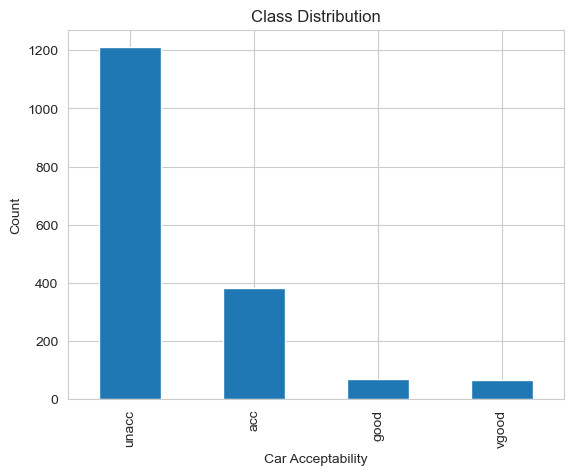

In [32]:
import matplotlib.pyplot as plt

car_data["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Car Acceptability")
plt.ylabel("Count")
plt.show()